# Main-manuscript analysis of the molecular-editing benchmark

This notebook contains only the analyses required for the current Scientific Reports main manuscript. Supporting-information analyses are kept in a separate notebook.

Main outputs:

- **Table 1**: applicability, median parent similarity, Murcko scaffold retention, median ΔQED, and median ΔSA Score
- **Table 2**: exact ±1 parent success rate for the eight descriptor-modification tasks
- **Figure 1**: parent success rate under limited candidate budgets
- **Figure 2**: task-wise median parent similarity among exact-success edits
- **Section 2.4 values**: similarity and Murcko retention among exact-success edits
- **Section 2.5 values**: selective success and collateral descriptor changes
- **Figure 3**: representative molecular edits across methods

The primary cross-method task analyses use the common set of parents accepted by REINVENT4 unless otherwise noted.


## Preparation


In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rdkit
from rdkit import Chem, DataStructs, RDConfig
from rdkit.Chem import QED, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFingerprintGenerator
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

# RDKit SA Score implementation
sa_score_dir = os.path.join(RDConfig.RDContribDir, "SA_Score")
if sa_score_dir not in sys.path:
    sys.path.append(sa_score_dir)
import sascorer

SEED = 42
N_PARENTS = 1000
N_CANDIDATES_PER_PARENT = 100

print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}, RDKit: {rdkit.__version__}")


NumPy: 2.4.6, Pandas: 3.0.5, RDKit: 2026.03.5


In [2]:
RESULTS_DIR = Path("../results")
FIGURE_DIR = RESULTS_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

METHOD_ORDER = [
    "scaffold-tuner",
    "Random local editing",
    "CReM",
    "REINVENT4 Mol2Mol",
]

METHOD_FILES = {
    "scaffold-tuner": RESULTS_DIR / "scaffold_tuner.csv",
    "Random local editing": RESULTS_DIR / "random_local_editing.csv",
    "CReM": RESULTS_DIR / "crem.csv",
    "REINVENT4 Mol2Mol": RESULTS_DIR / "reinvent4_mol2mol.csv",
}

PARENT_FILE = Path("../data/chembl_1000_parents.csv")
REINVENT_UNSUPPORTED_FILE = RESULTS_DIR / "reinvent4_unsupported_parents.csv"

TARGETS = {
    "HBD": "delta_hbd",
    "HBA": "delta_hba",
    "RotB": "delta_rotb",
    "Aromatic rings": "delta_ar",
}
DELTA_COLS = list(TARGETS.values())

TASK_ORDER = [
    "HBD increase", "HBD decrease",
    "HBA increase", "HBA decrease",
    "RotB increase", "RotB decrease",
    "Aromatic rings increase", "Aromatic rings decrease",
]

SCAFFOLD_MODE_BY_TASK = {
    ("HBD", "increase"): "add_hbd",
    ("HBD", "decrease"): "remove_hbd",
    ("HBA", "increase"): "add_hba",
    ("HBA", "decrease"): "remove_hba",
    ("RotB", "increase"): "add_rb",
    ("RotB", "decrease"): "remove_rb",
    ("Aromatic rings", "increase"): "add_ar",
    ("Aromatic rings", "decrease"): "remove_ar",
}


In [3]:
parents = pd.read_csv(PARENT_FILE)[["chembl_id", "smiles"]].drop_duplicates("chembl_id")
assert len(parents) == N_PARENTS

results = {name: pd.read_csv(path) for name, path in METHOD_FILES.items()}

required_cols = {
    "chembl_id", "parent_smiles", "generated_smiles",
    "delta_hbd", "delta_hba", "delta_ar", "delta_rotb",
}
for name, df in results.items():
    missing = required_cols - set(df.columns)
    assert not missing, f"{name}: missing columns {missing}"

unsupported_reinvent = set()
if REINVENT_UNSUPPORTED_FILE.exists():
    tmp = pd.read_csv(REINVENT_UNSUPPORTED_FILE)
    if "chembl_id" in tmp.columns:
        unsupported_reinvent = set(tmp["chembl_id"].dropna())
    else:
        smiles_col = next((c for c in ["parent_smiles", "smiles"] if c in tmp.columns), None)
        if smiles_col is not None:
            unsupported_smiles = set(tmp[smiles_col].dropna())
            unsupported_reinvent = set(
                parents.loc[parents["smiles"].isin(unsupported_smiles), "chembl_id"]
            )

common_parent_ids = pd.Index(
    parents.loc[~parents["chembl_id"].isin(unsupported_reinvent), "chembl_id"]
)

common_results = {
    name: df[df["chembl_id"].isin(common_parent_ids)].copy()
    for name, df in results.items()
}

print({name: df.shape for name, df in results.items()})
print(f"REINVENT4-applicable common subset: {len(common_parent_ids)} / {N_PARENTS} parents")


{'scaffold-tuner': (34499, 16), 'Random local editing': (30248, 15), 'CReM': (24992, 15), 'REINVENT4 Mol2Mol': (61388, 15)}
REINVENT4-applicable common subset: 929 / 1000 parents


### Shared helper functions


In [4]:
def task_specific_df(method, df, target, direction):
    """Return the candidate pool that was actually generated for a task."""
    if method != "scaffold-tuner":
        return df
    if "mode" not in df.columns:
        raise ValueError("scaffold_tuner.csv must contain a 'mode' column.")
    mode = SCAFFOLD_MODE_BY_TASK[(target, direction)]
    return df[df["mode"] == mode].copy()


def success_table(results_dict, denominator_parent_ids):
    denominator_parent_ids = pd.Index(denominator_parent_ids)
    rows = []
    for method in METHOD_ORDER:
        df_all = results_dict[method]
        for target, delta_col in TARGETS.items():
            other_cols = [c for c in DELTA_COLS if c != delta_col]
            for direction, sign in [("increase", 1), ("decrease", -1)]:
                df = task_specific_df(method, df_all, target, direction)
                exact = df[delta_col].eq(sign)
                selective = exact & df[other_cols].eq(0).all(axis=1)

                parent_exact = (
                    df.loc[exact, "chembl_id"].value_counts()
                    .reindex(denominator_parent_ids, fill_value=0).gt(0)
                )
                parent_selective = (
                    df.loc[selective, "chembl_id"].value_counts()
                    .reindex(denominator_parent_ids, fill_value=0).gt(0)
                )

                rows.append({
                    "method": method,
                    "target": target,
                    "direction": direction,
                    "n_candidates_in_task_pool": len(df),
                    "parent_success_percent": 100 * parent_exact.mean(),
                    "selective_parent_success_percent": 100 * parent_selective.mean(),
                    "candidate_exact_success_percent": 100 * exact.mean() if len(df) else np.nan,
                })
    out = pd.DataFrame(rows)
    out["task"] = out["target"] + " " + out["direction"]
    return out


morgan = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)


def murcko_smiles(mol):
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold, canonical=True)


def editing_quality(df):
    parent_cache = {}
    rows = []

    for _, r in df.iterrows():
        psmiles = str(r["parent_smiles"])
        gsmiles = str(r["generated_smiles"])

        if psmiles not in parent_cache:
            pmol = Chem.MolFromSmiles(psmiles)
            parent_cache[psmiles] = {
                "mol": pmol,
                "fp": morgan.GetFingerprint(pmol) if pmol is not None else None,
                "scaffold": murcko_smiles(pmol) if pmol is not None else None,
                "qed": QED.qed(pmol) if pmol is not None else np.nan,
                "sa": sascorer.calculateScore(pmol) if pmol is not None else np.nan,
            }

        p = parent_cache[psmiles]
        gmol = Chem.MolFromSmiles(gsmiles)
        valid = gmol is not None and p["mol"] is not None

        rec = r.to_dict()
        rec["valid_generated_smiles"] = valid

        if not valid:
            rec.update({
                "canonical_generated_smiles": np.nan,
                "tanimoto_to_parent": np.nan,
                "murcko_retained": False,
                "qed_parent": p["qed"], "qed": np.nan, "delta_qed": np.nan,
                "sa_score_parent": p["sa"], "sa_score": np.nan, "delta_sa_score": np.nan,
            })
        else:
            gfp = morgan.GetFingerprint(gmol)
            gqed = QED.qed(gmol)
            gsa = sascorer.calculateScore(gmol)
            rec.update({
                "canonical_generated_smiles": Chem.MolToSmiles(gmol, canonical=True, isomericSmiles=True),
                "tanimoto_to_parent": DataStructs.TanimotoSimilarity(p["fp"], gfp),
                "murcko_retained": p["scaffold"] == murcko_smiles(gmol),
                "qed_parent": p["qed"], "qed": gqed, "delta_qed": gqed - p["qed"],
                "sa_score_parent": p["sa"], "sa_score": gsa, "delta_sa_score": gsa - p["sa"],
            })
        rows.append(rec)

    return pd.DataFrame(rows)


In [5]:
# Precompute structural-quality metrics once for each method.
quality_results = {name: editing_quality(df) for name, df in results.items()}

# Primary task-success table on the common REINVENT4-applicable parent set.
success_common = success_table(common_results, common_parent_ids)

print(f"Common parent set: {len(common_parent_ids)} / {N_PARENTS}")
print("Shared quality and task-success tables prepared.")


Common parent set: 929 / 1000
Shared quality and task-success tables prepared.


## 2.1 Overall characteristics of generated molecules

The main-text table reports only the quantities currently used in Table 1: applicability, median Tanimoto similarity to the parent, Murcko scaffold retention, median ΔQED, and median ΔSA Score.


In [6]:
# Applicability / generation coverage
app_rows = []
for name, df in results.items():
    unsupported = len(unsupported_reinvent) if name == "REINVENT4 Mol2Mol" else 0
    app_rows.append({
        "method": name,
        "input_parents": N_PARENTS,
        "applicability_percent": 100 * (N_PARENTS - unsupported) / N_PARENTS,
        "parents_with_output": df["chembl_id"].nunique(),
    })

applicability_summary = pd.DataFrame(app_rows)
applicability_summary


,method,input_parents,applicability_percent,parents_with_output
0,scaffold-tuner,1000,100.0,818
1,Random local editing,1000,100.0,1000
2,CReM,1000,100.0,860
3,REINVENT4 Mol2Mol,1000,92.9,929


In [18]:
# Manuscript Table 1
quality_rows = []
for name in METHOD_ORDER:
    dfq = quality_results[name]
    quality_rows.append({
        "method": name,
        "median_similarity": dfq["tanimoto_to_parent"].median(),
        "murcko_retention_percent": 100 * dfq["murcko_retained"].mean(),
        "median_delta_qed": dfq["delta_qed"].median(),
        "median_delta_sa": dfq["delta_sa_score"].median(),
    })

quality_summary = pd.DataFrame(quality_rows)
main_table_1 = (
    applicability_summary[["method", "applicability_percent"]]
    .merge(quality_summary, on="method", how="left")
    .set_index("method")
    .reindex(METHOD_ORDER)
    .reset_index()
)

display(main_table_1.round({
    "applicability_percent": 1,
    "median_similarity": 3,
    "murcko_retention_percent": 1,
    "median_delta_qed": 3,
    "median_delta_sa": 3,
}))


,method,applicability_percent,median_similarity,murcko_retention_percent,median_delta_qed,median_delta_sa
0,scaffold-tuner,100.0,0.721,75.1,-0.055,0.110
1,Random local editing,100.0,0.717,78.0,-0.025,0.270
2,CReM,100.0,0.750,86.6,-0.026,0.084
3,REINVENT4 Mol2Mol,92.9,0.520,33.6,0.000,0.004


## 2.2 Property-directed editing across descriptor tasks

Parent success is defined as the presence of at least one candidate with the exact requested descriptor change (Δ = +1 or −1).


In [8]:
# Manuscript Table 2
main_table_2 = (
    success_common.pivot(index="task", columns="method", values="parent_success_percent")
    .reindex(index=TASK_ORDER, columns=METHOD_ORDER)
)

display(main_table_2.round(1))


method,scaffold-tuner,Random local editing,CReM,REINVENT4 Mol2Mol
task,,,,
HBD increase,69.8,100.0,69.2,94.3
HBD decrease,49.0,73.3,43.7,73.2
HBA increase,69.8,100.0,74.2,97.8
HBA decrease,59.8,85.6,43.2,88.7
RotB increase,15.2,84.8,83.7,98.1
RotB decrease,51.3,53.3,26.8,84.5
Aromatic rings increase,69.8,1.1,0.0,94.7
Aromatic rings decrease,0.0,62.9,0.0,53.9


## 2.3 Targeted proposal efficiency under a limited candidate budget

Candidate order is randomized within each task pool. The analysis is repeated 20 times for k = 1, 5, 10, 20, 50, and 100 candidates. The same parent denominator is retained when a method produces no candidate for a parent.


In [9]:
K_VALUES = [1, 5, 10, 20, 50, 100]
N_REPEATS = 20
efficiency_parent_ids = pd.Index(common_parent_ids)
efficiency_rows = []

for repeat in range(N_REPEATS):
    rng_seed = SEED + repeat
    for method in METHOD_ORDER:
        df_all = common_results[method]
        for target, delta_col in TARGETS.items():
            for direction, sign in [("increase", 1), ("decrease", -1)]:
                df_task = task_specific_df(method, df_all, target, direction)
                shuffled = df_task.sample(frac=1, random_state=rng_seed).copy()
                for k in K_VALUES:
                    sampled = shuffled.groupby("chembl_id", group_keys=False).head(k)
                    successful = (
                        sampled.loc[sampled[delta_col].eq(sign), "chembl_id"]
                        .value_counts().reindex(efficiency_parent_ids, fill_value=0).gt(0)
                    )
                    efficiency_rows.append({
                        "repeat": repeat,
                        "method": method,
                        "k": k,
                        "target": target,
                        "direction": direction,
                        "parent_success_percent": 100 * successful.mean(),
                    })

efficiency = pd.DataFrame(efficiency_rows)

efficiency_overall = (
    efficiency.groupby(["repeat", "method", "k"], as_index=False)["parent_success_percent"].mean()
    .groupby(["method", "k"], as_index=False)
    .agg(
        mean_parent_success_percent=("parent_success_percent", "mean"),
        sd_parent_success_percent=("parent_success_percent", "std"),
    )
)

efficiency_overall


,method,k,mean_parent_success_percent,sd_parent_success_percent
0,CReM,1,15.594053,0.364681
1,CReM,5,34.015070,0.255558
2,CReM,10,38.437164,0.258349
3,CReM,20,40.800592,0.174133
4,CReM,50,42.393703,0.056768
5,CReM,100,42.599569,0.000000
6,REINVENT4 Mol2Mol,1,17.146798,0.378195
7,REINVENT4 Mol2Mol,5,50.023547,0.345477
8,REINVENT4 Mol2Mol,10,65.020183,0.308226
9,REINVENT4 Mol2Mol,20,75.926399,0.285907


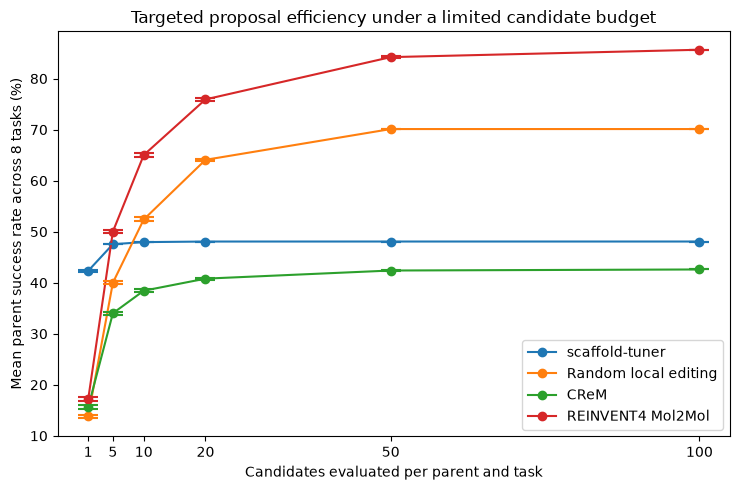

In [10]:
# Figure 1: limited-budget proposal efficiency with SD error bars
fig, ax = plt.subplots(figsize=(7.5, 5))
for method in METHOD_ORDER:
    part = efficiency_overall[efficiency_overall["method"] == method].sort_values("k")
    x = part["k"].to_numpy()
    y = part["mean_parent_success_percent"].to_numpy()
    sd = part["sd_parent_success_percent"].fillna(0).to_numpy()

    (line,) = ax.plot(x, y, marker="o", linewidth=1.5, label=method)
    ax.errorbar(
        x, y, yerr=sd, fmt="none",
        ecolor=line.get_color(), capsize=7, capthick=1.5,
        elinewidth=1.5, zorder=10,
    )

ax.set_xlabel("Candidates evaluated per parent and task")
ax.set_ylabel("Mean parent success rate across 8 tasks (%)")
ax.set_title("Targeted proposal efficiency under a limited candidate budget")
ax.set_xticks(K_VALUES)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "manuscript_equal_budget_success_curve.png", dpi=300, bbox_inches="tight")
plt.show()


## 2.4 Locality of successful edits

Only exact-success candidates are included. Figure 2 shows task-wise median Tanimoto similarity to the parent. Murcko scaffold retention is retained as a numerical supporting value and is reported in the Supporting Information.


In [11]:
successful_locality_rows = []
for method in METHOD_ORDER:
    dfq_all = quality_results[method]
    for target, delta_col in TARGETS.items():
        for direction, sign in [("increase", 1), ("decrease", -1)]:
            dfq = task_specific_df(method, dfq_all, target, direction)
            success = dfq[dfq[delta_col].eq(sign)].copy()
            successful_locality_rows.append({
                "method": method,
                "target": target,
                "direction": direction,
                "task": f"{target} {direction}",
                "n_successful_candidates": len(success),
                "median_success_similarity": success["tanimoto_to_parent"].median(),
                "successful_murcko_retention_percent": (
                    100 * success["murcko_retained"].mean() if len(success) else np.nan
                ),
            })

successful_locality = pd.DataFrame(successful_locality_rows)

similarity_table = (
    successful_locality.pivot(
        index="task", columns="method", values="median_success_similarity"
    )
    .reindex(index=TASK_ORDER, columns=METHOD_ORDER)
)

murcko_table = (
    successful_locality.pivot(
        index="task", columns="method", values="successful_murcko_retention_percent"
    )
    .reindex(index=TASK_ORDER, columns=METHOD_ORDER)
)

display(similarity_table.round(3))
display(murcko_table.round(1))


method,scaffold-tuner,Random local editing,CReM,REINVENT4 Mol2Mol
task,,,,
HBD increase,0.723,0.725,0.750,0.500
HBD decrease,0.733,0.714,0.739,0.500
HBA increase,0.750,0.717,0.754,0.516
HBA decrease,0.741,0.707,0.750,0.512
RotB increase,0.667,0.755,0.756,0.525
RotB decrease,0.720,0.744,0.712,0.518
Aromatic rings increase,0.695,0.477,NaN,0.525
Aromatic rings decrease,NaN,0.509,0.667,0.507


method,scaffold-tuner,Random local editing,CReM,REINVENT4 Mol2Mol
task,,,,
HBD increase,59.5,88.8,90.8,34.3
HBD decrease,99.9,87.1,87.5,35.8
HBA increase,99.9,75.1,90.8,32.6
HBA decrease,79.9,64.1,87.1,31.9
RotB increase,100.0,91.6,86.6,32.0
RotB decrease,83.0,77.5,60.1,34.3
Aromatic rings increase,0.0,0.0,NaN,0.0
Aromatic rings decrease,NaN,0.0,0.0,0.0


In [ ]:
# Figure 2: parent similarity among exact-success edits
# Each cell is the median Tanimoto similarity for successful candidates
# achieving the exact target descriptor change (Δ = +1 or -1).

FIGURE_TASK_LABELS = [
    "HBD +1", "HBD -1",
    "HBA +1", "HBA -1",
    "RotB +1", "RotB -1",
    "AR +1", "AR -1",
]

plot_matrix = similarity_table.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(8.2, 6.2))
im = ax.imshow(plot_matrix, aspect="auto", vmin=0, vmax=1)

ax.set_xticks(np.arange(len(METHOD_ORDER)))
ax.set_xticklabels(METHOD_ORDER, rotation=25, ha="right")
ax.set_yticks(np.arange(len(FIGURE_TASK_LABELS)))
ax.set_yticklabels(FIGURE_TASK_LABELS)

for i in range(plot_matrix.shape[0]):
    for j in range(plot_matrix.shape[1]):
        value = plot_matrix[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center")
        else:
            ax.text(j, i, "NA", ha="center", va="center")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Median Tanimoto similarity to parent")

ax.set_xlabel("Method")
ax.set_ylabel("Descriptor-modification task")
ax.set_title("Structural similarity to parent among successful edits")

fig.tight_layout()
figure2_path = FIGURE_DIR / "manuscript_figure_2_successful_edit_similarity.png"
fig.savefig(figure2_path, dpi=300, bbox_inches="tight")
plt.show()
print(figure2_path)


## 2.5 Trade-off between target success and descriptor selectivity

Selective parent success requires the exact target Δ = ±1 and no change in the other three benchmark descriptors. Collateral-change statistics are calculated among exact-success candidates.


In [12]:
# Selective parent success rates used in the main-text discussion
selective_success = (
    success_common.pivot(index="task", columns="method", values="selective_parent_success_percent")
    .reindex(index=TASK_ORDER, columns=METHOD_ORDER)
)

display(selective_success.round(1))


method,scaffold-tuner,Random local editing,CReM,REINVENT4 Mol2Mol
task,,,,
HBD increase,1.2,59.1,28.1,35.7
HBD decrease,0.4,43.6,28.2,38.3
HBA increase,15.2,94.9,53.1,60.3
HBA decrease,19.8,57.9,20.8,50.1
RotB increase,15.2,66.3,79.8,73.4
RotB decrease,8.2,22.4,14.1,52.7
Aromatic rings increase,0.3,0.3,0.0,37.1
Aromatic rings decrease,0.0,52.2,0.0,19.4


In [13]:
# Collateral-change summary among exact-success candidates
collateral_rows = []
for method in METHOD_ORDER:
    df_all = common_results[method]
    for target, delta_col in TARGETS.items():
        other_cols = [c for c in DELTA_COLS if c != delta_col]
        for direction, sign in [("increase", 1), ("decrease", -1)]:
            df = task_specific_df(method, df_all, target, direction)
            success = df[df[delta_col].eq(sign)].copy()
            if len(success) == 0:
                continue
            score = success[other_cols].abs().sum(axis=1)
            collateral_rows.append({
                "method": method,
                "task": f"{target} {direction}",
                "n_successful_candidates": len(success),
                "median_collateral_change_score": score.median(),
                "zero_collateral_candidate_percent": 100 * (score == 0).mean(),
            })

collateral_summary = pd.DataFrame(collateral_rows)
collateral_summary


,method,task,n_successful_candidates,median_collateral_change_score,zero_collateral_candidate_percent
0,scaffold-tuner,HBD increase,5245,3.0,0.686368
1,scaffold-tuner,HBD decrease,3225,2.0,0.465116
2,scaffold-tuner,HBA increase,4182,2.0,3.873745
3,scaffold-tuner,HBA decrease,4550,1.0,6.571429
4,scaffold-tuner,RotB increase,153,0.0,96.078431
5,scaffold-tuner,RotB decrease,1855,2.0,11.212938
6,scaffold-tuner,Aromatic rings increase,4196,3.0,0.071497
7,Random local editing,HBD increase,9437,1.0,9.219031
8,Random local editing,HBD decrease,2626,1.0,35.148515
9,Random local editing,HBA increase,11956,1.0,25.242556


## 2.6 Representative structural comparison across methods

Three representative tasks are shown in the main manuscript as Figure 3: HBD increase, AR increase, and RotB increase. Parent and candidate selection is deterministic to reduce visual cherry-picking.


In [14]:
def add_similarity_columns(df):
    if "tanimoto_to_parent" in df.columns:
        return df.copy()
    # use precomputed quality table by matching row index if possible
    return df.copy()


def ranked_candidate_for_parent(method, target, direction, chembl_id):
    delta_col = TARGETS[target]
    sign = 1 if direction == "increase" else -1
    other_cols = [c for c in DELTA_COLS if c != delta_col]

    df = task_specific_df(method, quality_results[method], target, direction)
    df = df[df["chembl_id"] == chembl_id].copy()
    if df.empty:
        return None

    df["exact_target_success"] = df[delta_col].eq(sign)
    df["target_error"] = (df[delta_col] - sign).abs()
    df["collateral_change_score"] = df[other_cols].abs().sum(axis=1)
    df = df.sort_values(
        ["exact_target_success", "target_error", "collateral_change_score", "tanimoto_to_parent", "generated_smiles"],
        ascending=[False, True, True, False, True],
        kind="mergesort",
    )
    return df.iloc[0]


def choose_representative_parent(target, direction):
    delta_col = TARGETS[target]
    sign = 1 if direction == "increase" else -1
    other_cols = [c for c in DELTA_COLS if c != delta_col]

    sdf = task_specific_df("scaffold-tuner", quality_results["scaffold-tuner"], target, direction)
    sdf = sdf[sdf["chembl_id"].isin(common_parent_ids)].copy()
    sdf = sdf[sdf[delta_col].eq(sign)].copy()
    if sdf.empty:
        raise ValueError(f"No scaffold-tuner successes for {target} {direction}")

    sdf["collateral_change_score"] = sdf[other_cols].abs().sum(axis=1)
    best_per_parent = (
        sdf.sort_values(
            ["chembl_id", "collateral_change_score", "tanimoto_to_parent", "generated_smiles"],
            ascending=[True, True, False, True], kind="mergesort"
        )
        .groupby("chembl_id", as_index=False, group_keys=False)
        .head(1)
    )
    med = best_per_parent["tanimoto_to_parent"].median()
    best_per_parent["distance_to_median_similarity"] = (
        best_per_parent["tanimoto_to_parent"] - med
    ).abs()
    chosen = best_per_parent.sort_values(
        ["distance_to_median_similarity", "chembl_id"], kind="mergesort"
    ).iloc[0]
    return chosen["chembl_id"]


REPRESENTATIVE_TASKS = [
    ("HBD", "increase"),
    ("Aromatic rings", "increase"),
    ("RotB", "increase"),
]

representative_rows = []
selected_parents = {}
for target, direction in REPRESENTATIVE_TASKS:
    chembl_id = choose_representative_parent(target, direction)
    selected_parents[(target, direction)] = chembl_id
    parent_smiles = parents.set_index("chembl_id").loc[chembl_id, "smiles"]

    for method in METHOD_ORDER:
        r = ranked_candidate_for_parent(method, target, direction, chembl_id)
        if r is None:
            representative_rows.append({
                "target": target, "direction": direction, "chembl_id": chembl_id,
                "method": method, "generated_smiles": np.nan, "exact_target_success": False,
                "target_delta": np.nan, "collateral_change_score": np.nan,
                "tanimoto_to_parent": np.nan,
            })
            continue
        representative_rows.append({
            "target": target, "direction": direction, "chembl_id": chembl_id,
            "method": method, "generated_smiles": r["generated_smiles"],
            "exact_target_success": bool(r["exact_target_success"]),
            "target_delta": r[TARGETS[target]],
            "collateral_change_score": r["collateral_change_score"],
            "tanimoto_to_parent": r["tanimoto_to_parent"],
            "delta_hbd": r["delta_hbd"], "delta_hba": r["delta_hba"],
            "delta_rotb": r["delta_rotb"], "delta_ar": r["delta_ar"],
        })

representative_selection_table = pd.DataFrame(representative_rows)
representative_selection_table


,target,direction,chembl_id,method,generated_smiles,exact_target_success,target_delta,collateral_change_score,tanimoto_to_parent,delta_hbd,delta_hba,delta_rotb,delta_ar
0,HBD,increase,CHEMBL101688,scaffold-tuner,CC1(C)Oc2ccc(C#N)cc2[C@@H](n2ccccc2=O)C1(O)CO,True,1.0,2.0,0.777778,1.0,1.0,1.0,0.0
1,HBD,increase,CHEMBL101688,Random local editing,CC1(C)Oc2ccc(C#N)cc2[C@@H](n2ccccc2=N)[C@]1(C)O,True,1.0,0.0,0.769231,1.0,0.0,0.0,0.0
2,HBD,increase,CHEMBL101688,CReM,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HBD,increase,CHEMBL101688,REINVENT4 Mol2Mol,CC1(C)Oc2ccc(C#N)cc2C(NC(=O)c2ccc(Cl)c(Cl)c2)C...,True,1.0,1.0,0.454545,1.0,0.0,1.0,0.0
4,Aromatic rings,increase,CHEMBL107590,scaffold-tuner,CC(C)(Cc1ccccc1)c1ccc(C#N)cc1NC(=O)Nc1cnccn1,True,1.0,3.0,0.727273,0.0,0.0,3.0,1.0
5,Aromatic rings,increase,CHEMBL107590,Random local editing,CC(C)(C)c1ccc(C#N)cc1NC(=S)Nc1cnccn1,False,0.0,0.0,0.775510,0.0,0.0,0.0,0.0
6,Aromatic rings,increase,CHEMBL107590,CReM,CC(C)(N)c1ccc(C#N)cc1NC(=O)Nc1cnccn1,False,0.0,3.0,0.833333,1.0,1.0,1.0,0.0
7,Aromatic rings,increase,CHEMBL107590,REINVENT4 Mol2Mol,CC(C)(C)c1ccc(C(C)(C)C)c(NC(=O)Nc2cccc3nccnc23)c1,True,1.0,1.0,0.423729,0.0,-1.0,0.0,1.0
8,RotB,increase,CHEMBL100715,scaffold-tuner,CCC(N)CC(NCc1ccccc1)C(=O)N1CCCCC1,True,1.0,0.0,0.666667,0.0,0.0,1.0,0.0
9,RotB,increase,CHEMBL100715,Random local editing,CNCC[C@H](NCc1ccccc1)C(=O)N1CCCCC1,True,1.0,0.0,0.772727,0.0,0.0,1.0,0.0


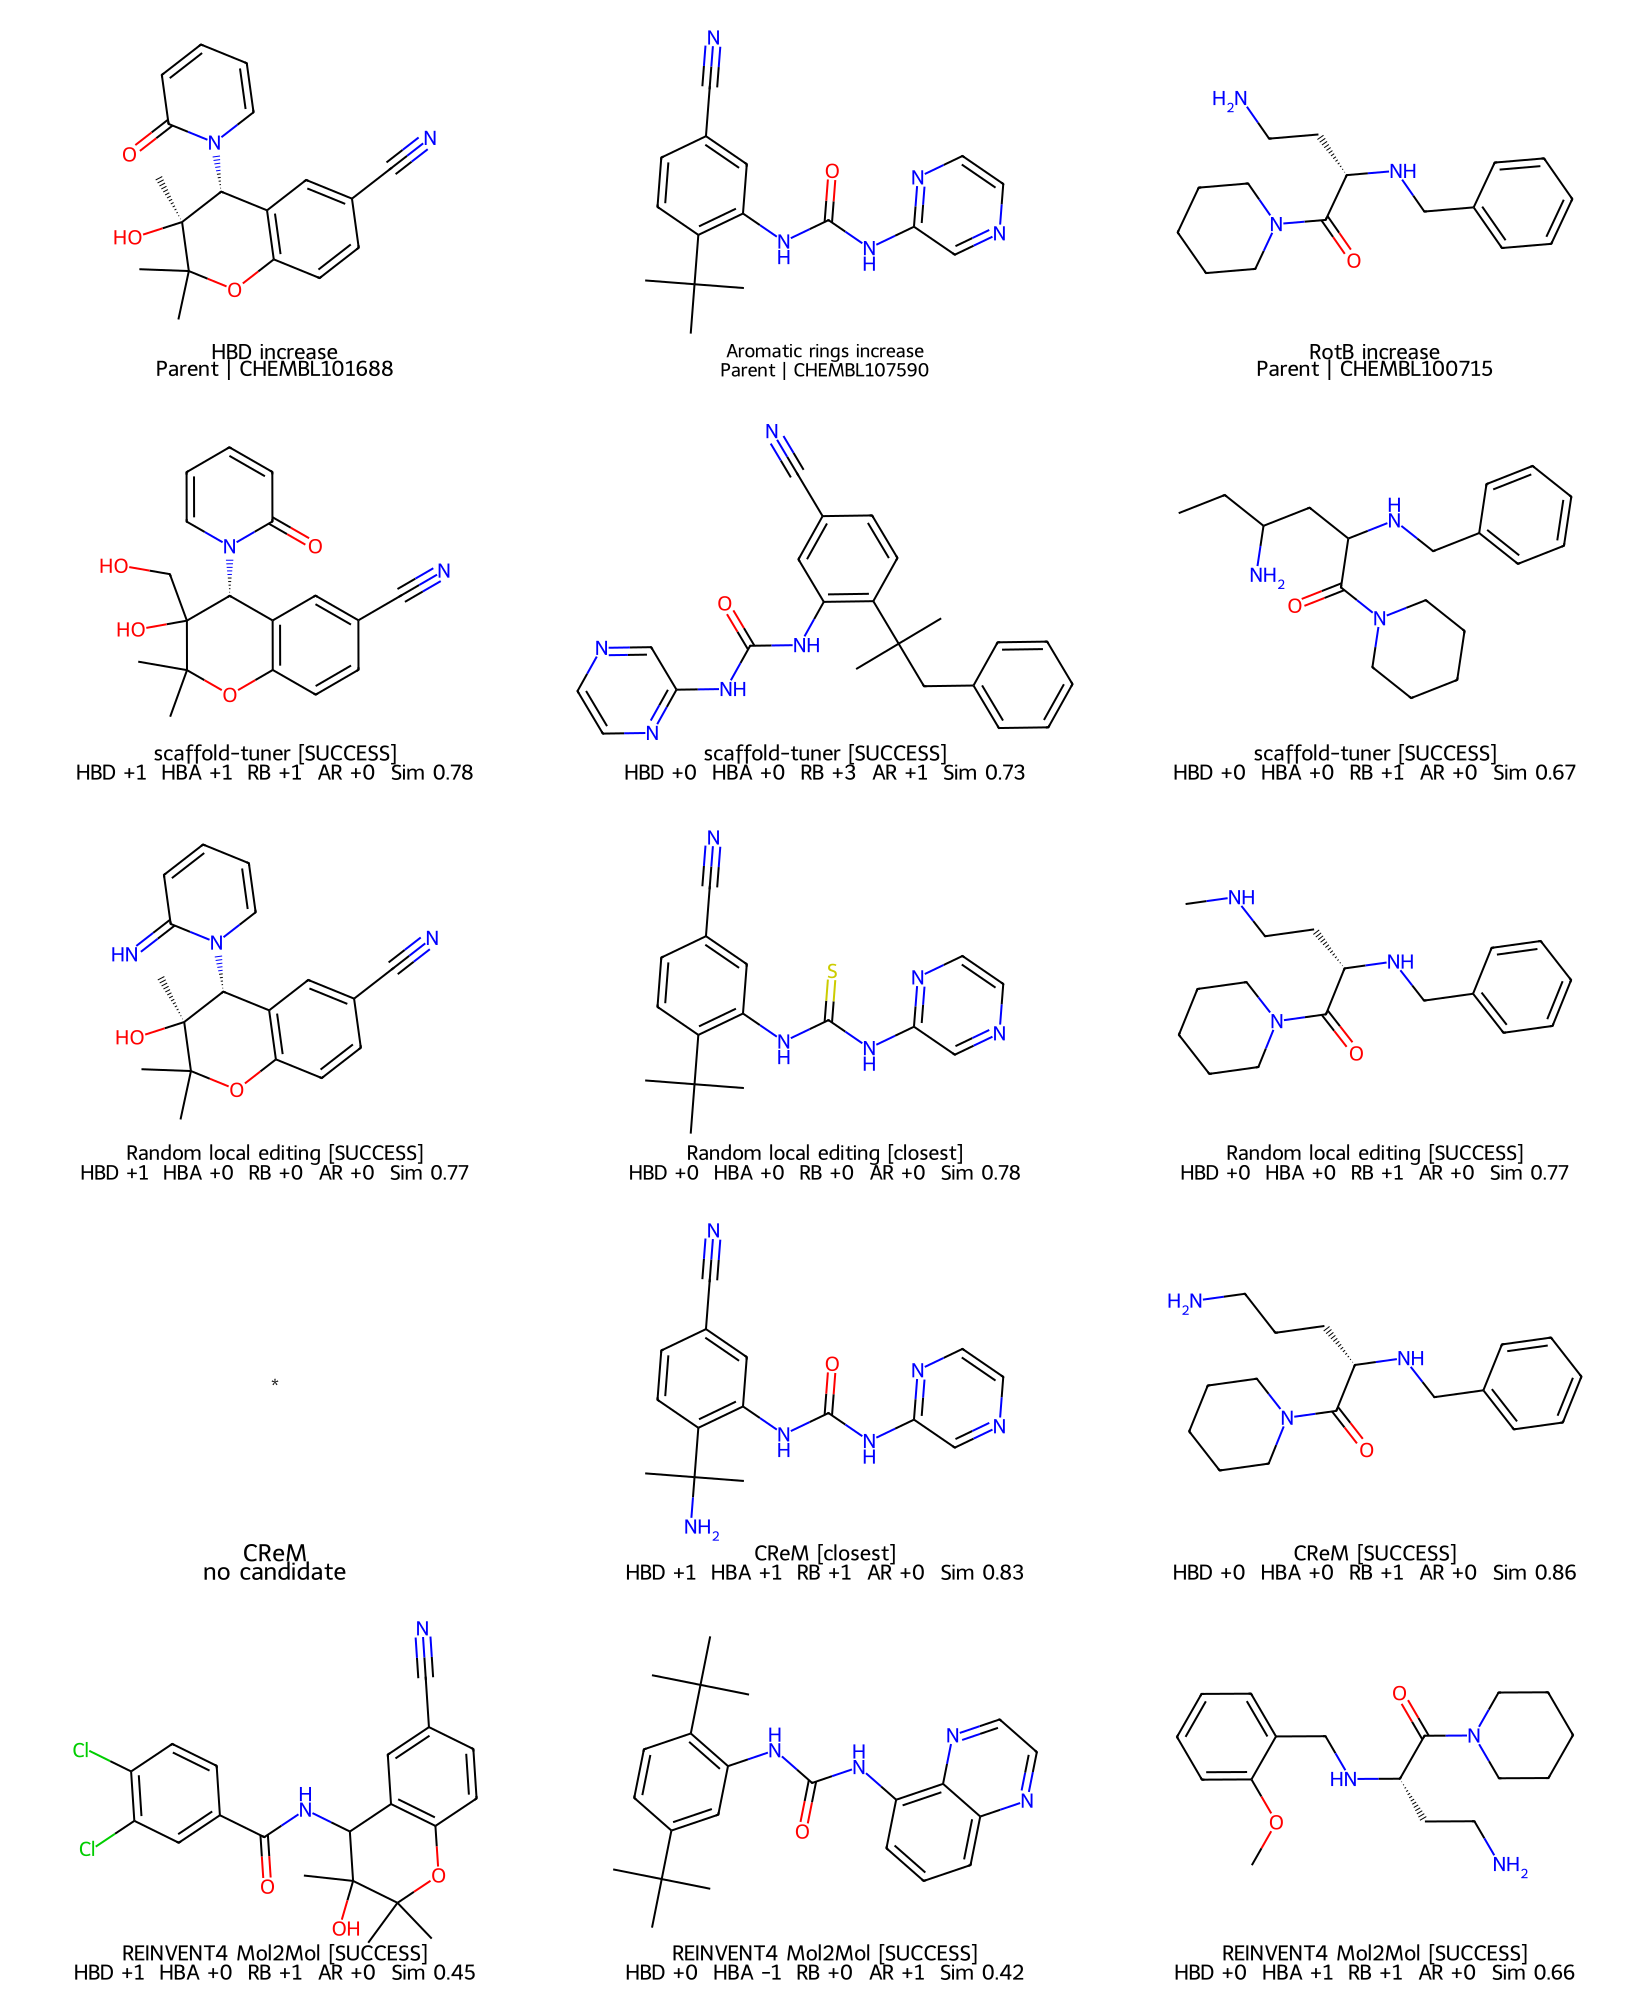

../results/figures/manuscript_representative_structures_all_methods_vertical.png


In [15]:
# Figure 3: representative structures arranged vertically
# Rows = Parent + four methods
# Columns = representative tasks

from rdkit.Chem.Draw import rdMolDraw2D

parent_lookup = parents.set_index("chembl_id")["smiles"].to_dict()

all_mols = []
all_legends = []

for target, direction in REPRESENTATIVE_TASKS:
    chembl_id = selected_parents[(target, direction)]
    parent_smiles = parent_lookup[chembl_id]
    task_label = f"{target} {direction}"

    # Parent molecule
    all_mols.append(Chem.MolFromSmiles(parent_smiles))
    all_legends.append(
        f"{task_label}\nParent | {chembl_id}"
    )

    part = representative_selection_table[
        (representative_selection_table["target"] == target)
        & (representative_selection_table["direction"] == direction)
        & (representative_selection_table["chembl_id"] == chembl_id)
    ]

    # Four comparison methods
    for method in METHOD_ORDER:
        row = part[part["method"] == method].iloc[0]

        if pd.isna(row["generated_smiles"]):
            all_mols.append(Chem.MolFromSmiles("*"))
            all_legends.append(
                f"{method}\nno candidate"
            )
        else:
            all_mols.append(Chem.MolFromSmiles(row["generated_smiles"]))

            status = "SUCCESS" if row["exact_target_success"] else "closest"

            all_legends.append(
                f"{method} [{status}]\n"
                f"HBD {row['delta_hbd']:+.0f}  "
                f"HBA {row['delta_hba']:+.0f}  "
                f"RotB {row['delta_rotb']:+.0f}  "
                f"AR {row['delta_ar']:+.0f}  "
                f"Sim {row['tanimoto_to_parent']:.2f}"
            )

# Reorder:
# columns = tasks
# rows    = Parent, scaffold-tuner, Random, CReM, REINVENT4
n_tasks = len(REPRESENTATIVE_TASKS)
n_rows_per_task = 1 + len(METHOD_ORDER)

reordered_mols = []
reordered_legends = []

for row_idx in range(n_rows_per_task):
    for task_idx in range(n_tasks):
        idx = task_idx * n_rows_per_task + row_idx
        reordered_mols.append(all_mols[idx])
        reordered_legends.append(all_legends[idx])

# Drawing options
draw_options = rdMolDraw2D.MolDrawOptions()

# Legend text size
draw_options.legendFontSize = 36

# Atom label sizes in molecular structures
draw_options.minFontSize = 20
draw_options.maxFontSize = 32

# Generate one combined figure
img = Draw.MolsToGridImage(
    reordered_mols,
    molsPerRow=n_tasks,
    subImgSize=(550, 400),
    legends=reordered_legends,
    useSVG=False,
    drawOptions=draw_options,
)

path = FIGURE_DIR / "manuscript_figure_3_representative_structures.png"

if hasattr(img, "save"):
    img.save(path)
elif hasattr(img, "data"):
    path.write_bytes(img.data)
else:
    raise TypeError(f"Unexpected image type: {type(img)}")

display(img)
print(path)


### Export main-manuscript tables


In [16]:
main_table_1.to_csv(
    RESULTS_DIR / "manuscript_table_1_overall_characteristics.csv", index=False
)
main_table_2.to_csv(
    RESULTS_DIR / "manuscript_table_2_task_success.csv"
)
efficiency_overall.to_csv(
    RESULTS_DIR / "manuscript_figure_1_candidate_budget_values.csv", index=False
)
successful_locality.to_csv(
    RESULTS_DIR / "manuscript_section_2_4_successful_edit_locality.csv", index=False
)
similarity_table.to_csv(
    RESULTS_DIR / "manuscript_figure_2_successful_edit_similarity_values.csv"
)
selective_success.to_csv(
    RESULTS_DIR / "manuscript_section_2_5_selective_success.csv"
)
collateral_summary.to_csv(
    RESULTS_DIR / "manuscript_section_2_5_collateral_changes.csv", index=False
)
representative_selection_table.to_csv(
    RESULTS_DIR / "manuscript_figure_3_representative_selection.csv", index=False
)

print("Main-manuscript analysis outputs saved to:", RESULTS_DIR)


Main-manuscript analysis outputs saved to: ../results
